## Overview

This notebook covers a implementation of a basic neural network. It shows initalizing weights and set up an architecture

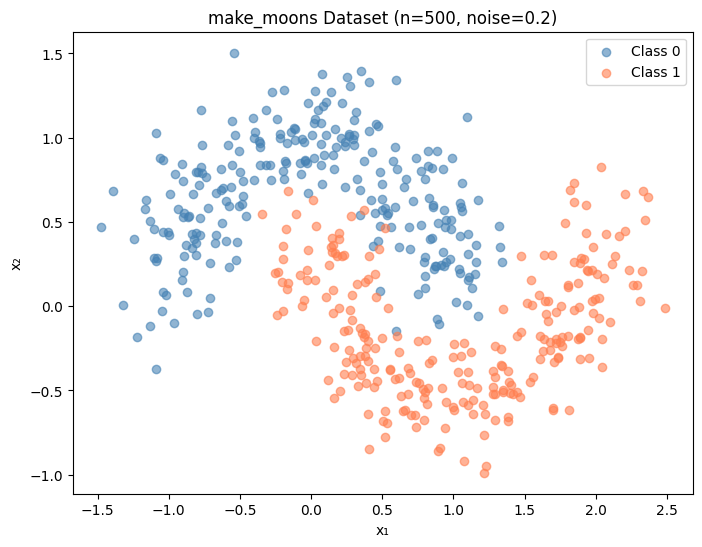

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier

# Generate the dataset
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(X[y==0, 0], X[y==0, 1], color='steelblue', label='Class 0', alpha=0.6)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='coral', label='Class 1', alpha=0.6)
plt.title('make_moons Dataset (n=500, noise=0.2)')
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.legend()
plt.show()

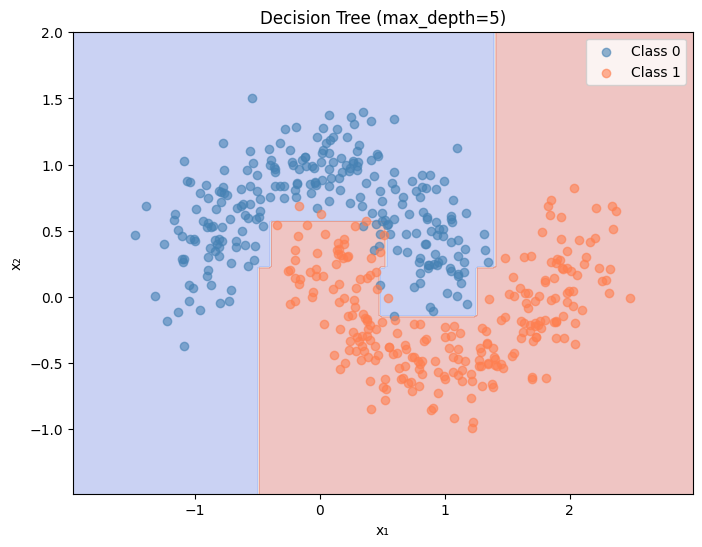

In [10]:
def plot_decision_boundary(model_predict, X, y, title, ax=None):
    """Plot the decision boundary of a classifier."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model_predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='steelblue', label='Class 0', alpha=0.6)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='coral', label='Class 1', alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')
    ax.legend()

# Train and plot decision tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X, y)
plot_decision_boundary(dt.predict, X, y, 'Decision Tree (max_depth=5)')
plt.show()

In [11]:
def sigmoid(z):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    """Derivative of sigmoid, given the sigmoid output a = sigmoid(z)."""
    return a * (1 - a)

In [12]:
z = np.array([-5, -1, 0, 1, 5])
print(f"sigmoid({z}) = {sigmoid(z).round(4)}")
# Expected: [0.0067, 0.2689, 0.5, 0.7311, 0.9933]

sigmoid([-5 -1  0  1  5]) = [0.0067 0.2689 0.5    0.7311 0.9933]


In [13]:
np.random.seed(42)

# Shapes: (rows = inputs from previous layer, cols = neurons in this layer)
W1 = np.random.randn(2, 8) * 0.5   # (2 inputs, 8 hidden) → shape (2, 8)
b1 = np.zeros((1, 8))               # (1, 8)

W2 = np.random.randn(8, 1) * 0.5   # (8 hidden, 1 output) → shape (8, 1)
b2 = np.zeros((1, 1))               # (1, 1)

print(f"W1 shape: {W1.shape}")  # (2, 8)
print(f"b1 shape: {b1.shape}")  # (1, 8)
print(f"W2 shape: {W2.shape}")  # (8, 1)
print(f"b2 shape: {b2.shape}")  # (1, 1)

W1 shape: (2, 8)
b1 shape: (1, 8)
W2 shape: (8, 1)
b2 shape: (1, 1)


In [14]:
def forward(X, W1, b1, W2, b2):
    """
    Forward pass through the network.

    X shape:  (n_samples, 2)
    Z1 shape: (n_samples, 8)  — hidden layer pre-activation
    A1 shape: (n_samples, 8)  — hidden layer post-activation
    Z2 shape: (n_samples, 1)  — output pre-activation
    A2 shape: (n_samples, 1)  — output (prediction)
    """
    Z1 = X @ W1 + b1            # (n, 2) @ (2, 8) + (1, 8) = (n, 8)
    A1 = sigmoid(Z1)            # (n, 8)

    Z2 = A1 @ W2 + b2           # (n, 8) @ (8, 1) + (1, 1) = (n, 1)
    A2 = sigmoid(Z2)            # (n, 1)

    return Z1, A1, Z2, A2

# Test with a few samples
Z1, A1, Z2, A2 = forward(X[:5], W1, b1, W2, b2)
print(f"Predictions for first 5 samples: {A2.flatten().round(4)}")
print(f"Actual labels:                   {y[:5]}")

Predictions for first 5 samples: [0.2532 0.291  0.2352 0.368  0.3455]
Actual labels:                   [1 0 1 0 0]


In [15]:
def compute_loss(y_true, y_pred):
    """Binary cross-entropy loss."""
    n = y_true.shape[0]
    # Clip predictions to avoid log(0)
    y_pred = np.clip(y_pred, 1e-8, 1 - 1e-8)
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

In [16]:
def backward(X, y_true, Z1, A1, Z2, A2, W1, b1, W2, b2):
    """
    Backward pass — compute gradients for all weights and biases.

    Returns gradients: dW1, db1, dW2, db2
    """
    n = X.shape[0]
    y_true = y_true.reshape(-1, 1)    # (n, 1)

    # Output layer error
    dZ2 = A2 - y_true                  # (n, 1) — how wrong is each prediction?

    # Gradients for W2, b2
    dW2 = (A1.T @ dZ2) / n             # (8, 1) — average gradient across samples
    db2 = np.sum(dZ2, axis=0, keepdims=True) / n  # (1, 1)

    # Propagate error back to hidden layer
    dA1 = dZ2 @ W2.T                   # (n, 8)
    dZ1 = dA1 * sigmoid_derivative(A1) # (n, 8) — chain rule with activation

    # Gradients for W1, b1
    dW1 = (X.T @ dZ1) / n              # (2, 8)
    db1 = np.sum(dZ1, axis=0, keepdims=True) / n  # (1, 8)

    return dW1, db1, dW2, db2

In [17]:
# Hyperparameters
learning_rate = 0.5
epochs = 1000

# Re-initialize weights
np.random.seed(42)
W1 = np.random.randn(2, 8) * 0.5
b1 = np.zeros((1, 8))
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros((1, 1))

# Track loss for plotting
losses = []

for epoch in range(epochs):
    # Forward
    Z1, A1, Z2, A2 = forward(X, W1, b1, W2, b2)

    # Loss
    loss = compute_loss(y, A2)
    losses.append(loss)

    # Backward
    dW1, db1, dW2, db2 = backward(X, y, Z1, A1, Z2, A2, W1, b1, W2, b2)

    # Update weights (gradient descent)
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if epoch % 100 == 0:
        accuracy = np.mean((A2.flatten() > 0.5) == y)
        print(f"Epoch {epoch:4d} | Loss: {loss:.4f} | Accuracy: {accuracy:.3f}")

print(f"\nFinal — Loss: {losses[-1]:.4f} | Accuracy: {np.mean((A2.flatten() > 0.5) == y):.3f}")

Epoch    0 | Loss: 0.7948 | Accuracy: 0.500
Epoch  100 | Loss: 1.0295 | Accuracy: 0.846
Epoch  200 | Loss: 1.2687 | Accuracy: 0.860
Epoch  300 | Loss: 1.3746 | Accuracy: 0.862
Epoch  400 | Loss: 1.4233 | Accuracy: 0.860
Epoch  500 | Loss: 1.4460 | Accuracy: 0.860
Epoch  600 | Loss: 1.4573 | Accuracy: 0.860
Epoch  700 | Loss: 1.4636 | Accuracy: 0.860
Epoch  800 | Loss: 1.4678 | Accuracy: 0.860
Epoch  900 | Loss: 1.4710 | Accuracy: 0.860

Final — Loss: 1.4737 | Accuracy: 0.860


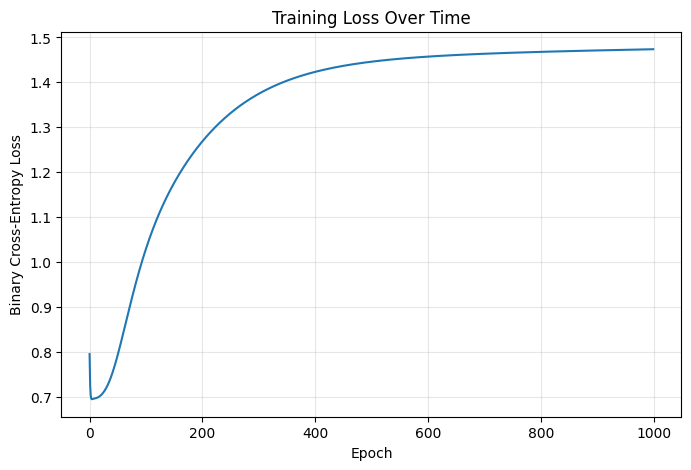

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.grid(True, alpha=0.3)
plt.show()

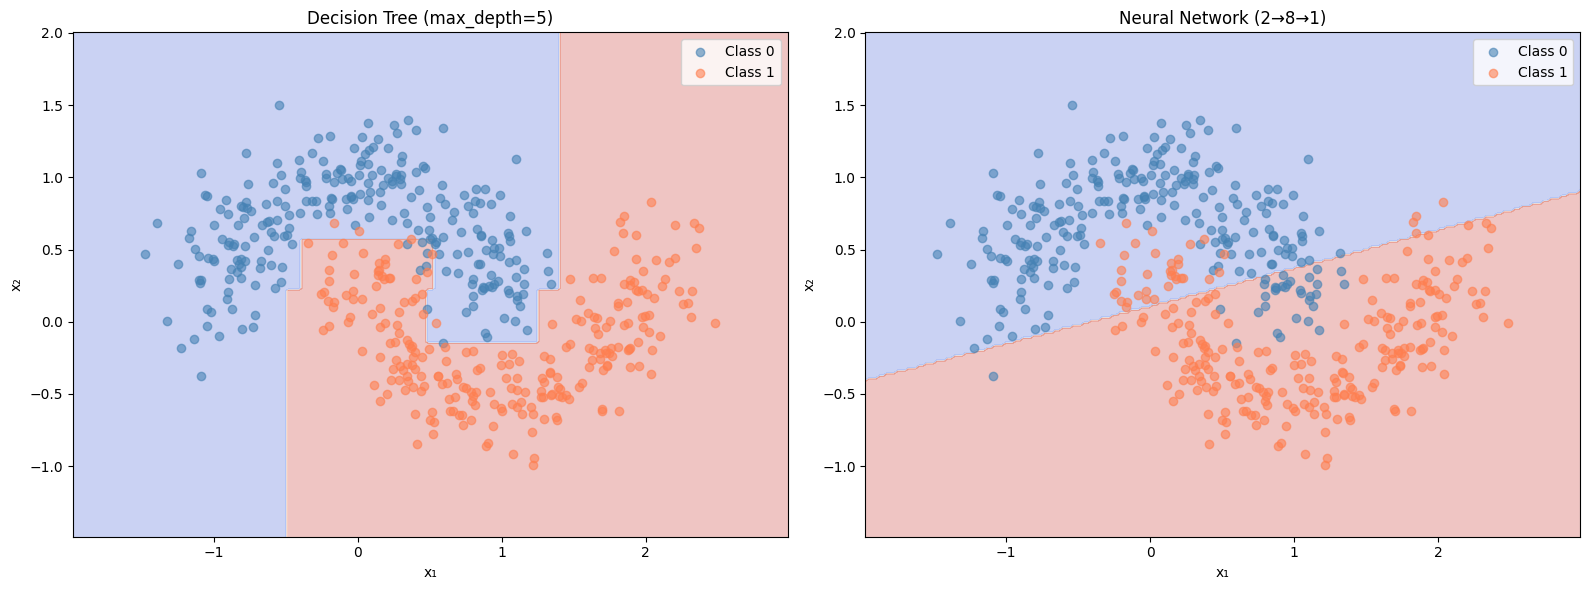

In [19]:
def nn_predict(X_input):
    """Predict using our trained neural network."""
    _, _, _, A2 = forward(X_input, W1, b1, W2, b2)
    return (A2.flatten() > 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Decision tree
plot_decision_boundary(dt.predict, X, y, 'Decision Tree (max_depth=5)', ax=axes[0])

# Neural network
plot_decision_boundary(nn_predict, X, y, 'Neural Network (2→8→1)', ax=axes[1])

plt.tight_layout()
plt.show()

#PyTorch implementation of the same neural network
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# --- Convert data to PyTorch tensors ---
X_tensor = torch.FloatTensor(X)
y_tensor = torch.FloatTensor(y).reshape(-1, 1)

# --- Define the model ---
# Mirrors your architecture: 2 inputs → 8 hidden (sigmoid) → 1 output (sigmoid)
class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 8)
        self.layer2 = nn.Linear(8, 1)

    def forward(self, x):
        x = torch.sigmoid(self.layer1(x))
        x = torch.sigmoid(self.layer2(x))
        return x

# --- Initialize model ---
torch.manual_seed(42)
model = NeuralNet()

# Match your original weight scale of 0.5
with torch.no_grad():
    model.layer1.weight.data *= 0.5
    model.layer2.weight.data *= 0.5

# --- Hyperparameters ---
criterion = nn.BCELoss()                              # same loss as compute_loss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)  # same lr as yours

# --- Training loop ---
losses = []

for epoch in range(1000):
    # Forward pass
    A2 = model(X_tensor)

    # Loss
    loss = criterion(A2, y_tensor)
    losses.append(loss.item())

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        preds = (A2.detach() > 0.5).float()
        accuracy = (preds == y_tensor).float().mean()
        print(f"Epoch {epoch:4d} | Loss: {loss:.4f} | Accuracy: {accuracy:.3f}")

print(f"\nFinal — Loss: {losses[-1]:.4f} | Accuracy: {(((model(X_tensor).detach() > 0.5).float() == y_tensor).float().mean()):.3f}")

# --- Plot loss curve ---
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

#PyTorch implementation of GNN

import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

# --- Dataset ---
dataset = Planetoid(root="/tmp/pyg_data", name="Cora")
data = dataset[0]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data = data.to(device)


# --- Model ---
class GCN(torch.nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x


model = GCN(dataset.num_node_features, 16, dataset.num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# --- Training ---
model.train()
for epoch in range(1, 201):
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        model.eval()
        with torch.no_grad():
            pred = model(data.x, data.edge_index).argmax(dim=1)
            correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
            acc = correct / data.test_mask.sum()
        print(f"Epoch {epoch:>3d}  Loss: {loss:.4f}  Test Acc: {acc:.4f}")
        model.train()